# 04 — Kaplan-Meier Survival Analysis
### TCGA-BRCA Cancer Survival ML Pipeline

**Goal:** Use the predicted risk scores from notebook 03 to stratify patients into High Risk / Low Risk groups, then visualize and statistically test whether those groups have meaningfully different survival outcomes using Kaplan-Meier curves.

**Why this matters:**  
AUC tells us how well the model ranks patients — but Kaplan-Meier curves show whether those rankings correspond to *real, clinically meaningful differences in survival*. A model with AUC 0.71 that produces clearly separated KM curves is genuinely useful for clinical stratification.

**Input:**
- `data/processed/test_risk_scores.csv` — predicted scores from best model (Random Forest)
- `data/processed/brca_features.csv` — full dataset for subgroup analyses

**Outputs:**
- `outputs/plots/km_main.png` — Main KM curves: High Risk vs Low Risk
- `outputs/plots/km_by_stage.png` — KM curves stratified by tumor stage
- `outputs/plots/km_by_age_group.png` — KM curves stratified by age group
- `outputs/plots/km_risk_score_distribution.png` — Risk score distribution plot

---
**Install if needed:**
```bash
pip install lifelines
```

## 0. Imports & Config

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# Lifelines: survival analysis library
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

PROC_DIR = 'data/processed/'
PLOT_DIR = 'outputs/plots/'
os.makedirs(PLOT_DIR, exist_ok=True)

# Colors: red = high risk, green = low risk (universal convention)
COLORS = {
    'High Risk' : '#e74c3c',
    'Low Risk'  : '#2ecc71',
}

import lifelines
print(f'lifelines version : {lifelines.__version__}')
print('Imports ready.')

lifelines version : 0.30.3
Imports ready.


## 1. Load Risk Scores

This file was saved at the end of notebook 03. It contains:
- `risk_score` — the model's predicted probability of being high-risk  
- `risk_group` — "High Risk" / "Low Risk" based on median threshold  
- `survival_time` — days to death or last follow-up  
- `event` — 1 if the patient died, 0 if censored (still alive or lost to follow-up)

In [2]:
risk_df  = pd.read_csv(PROC_DIR + 'test_risk_scores.csv')
full_df  = pd.read_csv(PROC_DIR + 'brca_features.csv')

print(f'Test set patients: {len(risk_df)}')
print(f'\nRisk group breakdown:')
for grp in ['High Risk', 'Low Risk']:
    sub = risk_df[risk_df['risk_group'] == grp]
    print(f'  {grp}: {len(sub)} patients, {sub["event"].sum()} deaths '
          f'({sub["event"].mean()*100:.1f}% mortality)')

print(f'\nSurvival time (days) by group:')
for grp in ['High Risk', 'Low Risk']:
    sub = risk_df[risk_df['risk_group'] == grp]['survival_time']
    print(f'  {grp}: median={sub.median():.0f}d  mean={sub.mean():.0f}d  '
          f'range={sub.min():.0f}–{sub.max():.0f}d')

Test set patients: 208

Risk group breakdown:
  High Risk: 104 patients, 26 deaths (25.0% mortality)
  Low Risk: 104 patients, 5 deaths (4.8% mortality)

Survival time (days) by group:
  High Risk: median=720d  mean=1255d  range=0–8556d
  Low Risk: median=916d  mean=1278d  range=19–8008d


## 2. Risk Score Distribution

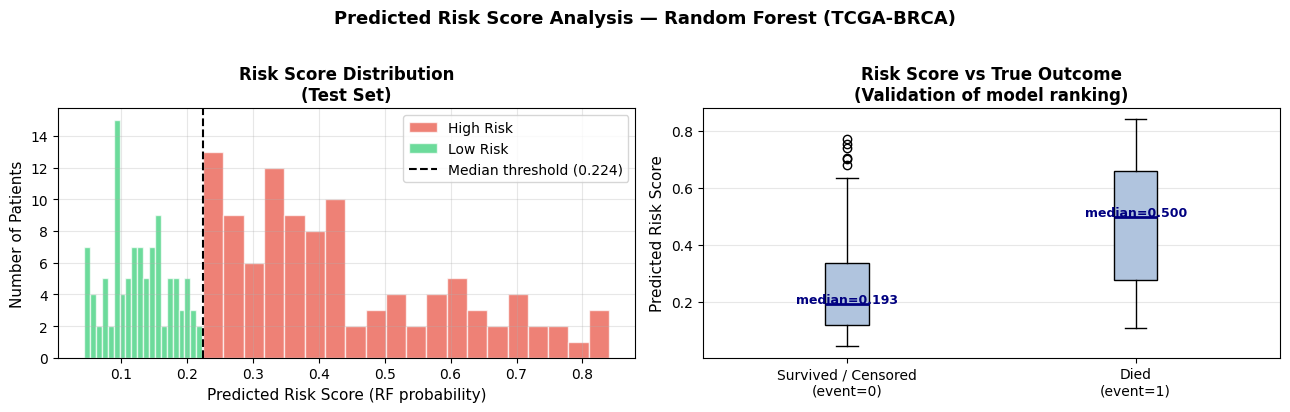

Saved: outputs/plots/km_risk_score_distribution.png


In [3]:
threshold = risk_df['risk_score'].median()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram of risk scores, colored by group ---
for grp, color in COLORS.items():
    sub = risk_df[risk_df['risk_group'] == grp]['risk_score']
    axes[0].hist(sub, bins=20, alpha=0.7, color=color, label=grp, edgecolor='white')
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'Median threshold ({threshold:.3f})')
axes[0].set_xlabel('Predicted Risk Score (RF probability)', fontsize=11)
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_title('Risk Score Distribution\n(Test Set)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# --- Risk score by true outcome (did they actually die?) ---
died  = risk_df[risk_df['event'] == 1]['risk_score']
alive = risk_df[risk_df['event'] == 0]['risk_score']
axes[1].boxplot(
    [alive.values, died.values],
    labels=['Survived / Censored\n(event=0)', 'Died\n(event=1)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='navy', linewidth=2)
)
axes[1].set_ylabel('Predicted Risk Score', fontsize=11)
axes[1].set_title('Risk Score vs True Outcome\n(Validation of model ranking)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Annotate medians
for i, (vals, label) in enumerate([(alive, 'Alive'), (died, 'Died')], 1):
    axes[1].text(i, vals.median() + 0.003, f'median={vals.median():.3f}',
                 ha='center', fontsize=9, color='navy', fontweight='bold')

plt.suptitle('Predicted Risk Score Analysis — Random Forest (TCGA-BRCA)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'km_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/km_risk_score_distribution.png')

## 3. Main Kaplan-Meier Curves: High Risk vs Low Risk

**How to read a KM curve:**
- The Y-axis shows the probability of *still being alive* at each time point
- The X-axis is time in days from diagnosis
- Each vertical drop = one or more deaths occurred at that time
- Small tick marks (|) on the curve = censored patients (lost to follow-up or still alive at study end)
- **If the two curves separate cleanly → the model is identifying a real biological difference in prognosis**

**Log-rank test:** Tests the null hypothesis that the two survival curves are identical. A p-value < 0.05 means the separation is statistically significant.

In [4]:
# --- Fit KM curves for each risk group ---
kmf_high = KaplanMeierFitter(label='High Risk')
kmf_low  = KaplanMeierFitter(label='Low Risk')

high_risk_df = risk_df[risk_df['risk_group'] == 'High Risk']
low_risk_df  = risk_df[risk_df['risk_group'] == 'Low Risk']

kmf_high.fit(high_risk_df['survival_time'], high_risk_df['event'])
kmf_low.fit(low_risk_df['survival_time'],   low_risk_df['event'])

# --- Log-rank test ---
logrank_result = logrank_test(
    high_risk_df['survival_time'], low_risk_df['survival_time'],
    event_observed_A=high_risk_df['event'],
    event_observed_B=low_risk_df['event']
)
p_value  = logrank_result.p_value
test_stat = logrank_result.test_statistic

print(f'Log-rank test statistic : {test_stat:.3f}')
print(f'p-value                 : {p_value:.4f}')
print(f'Result: {"Statistically significant (p < 0.05)" if p_value < 0.05 else "Not significant (p >= 0.05)"}')
print(f'\nMedian survival (High Risk) : {kmf_high.median_survival_time_:.0f} days')
print(f'Median survival (Low Risk)  : {kmf_low.median_survival_time_:.0f} days')

Log-rank test statistic : 14.768
p-value                 : 0.0001
Result: Statistically significant (p < 0.05)

Median survival (High Risk) : 2636 days
Median survival (Low Risk)  : inf days


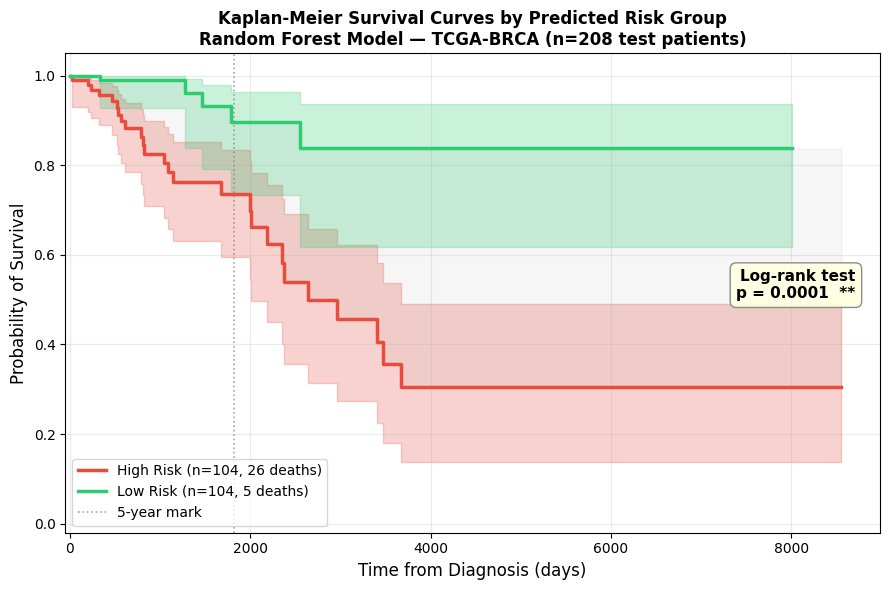

Saved: outputs/plots/km_main.png

Key result: High-risk group median survival = 2636 days vs Low-risk = inf days


In [5]:
# --- Plot main KM curves ---
fig, ax = plt.subplots(figsize=(9, 6))

kmf_high.plot_survival_function(
    ax=ax, ci_show=True,
    color=COLORS['High Risk'], linewidth=2.5,
    label=f'High Risk (n={len(high_risk_df)}, {int(high_risk_df["event"].sum())} deaths)'
)
kmf_low.plot_survival_function(
    ax=ax, ci_show=True,
    color=COLORS['Low Risk'], linewidth=2.5,
    label=f'Low Risk (n={len(low_risk_df)}, {int(low_risk_df["event"].sum())} deaths)'
)

# Annotate p-value on plot
p_text = f'p = {p_value:.4f}' if p_value >= 0.0001 else 'p < 0.0001'
sig_text = '**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.')
ax.text(0.97, 0.55,
        f'Log-rank test\n{p_text}  {sig_text}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

# Reference lines at 5 years
ax.axvline(1825, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='5-year mark')

ax.set_xlabel('Time from Diagnosis (days)', fontsize=12)
ax.set_ylabel('Probability of Survival', fontsize=12)
ax.set_title(
    'Kaplan-Meier Survival Curves by Predicted Risk Group\n'
    'Random Forest Model — TCGA-BRCA (n=208 test patients)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim([-0.02, 1.05])
ax.set_xlim(left=-50)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.25)

# Add shading between curves to emphasize separation
t_vals = np.linspace(0, risk_df['survival_time'].max(), 500)
sf_high = kmf_high.survival_function_at_times(t_vals).values
sf_low  = kmf_low.survival_function_at_times(t_vals).values
ax.fill_between(t_vals, sf_high, sf_low, alpha=0.07, color='gray', label='_nolegend_')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'km_main.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/km_main.png')
print(f'\nKey result: High-risk group median survival = {kmf_high.median_survival_time_:.0f} days '
      f'vs Low-risk = {kmf_low.median_survival_time_:.0f} days')

## 4. KM Curves by Tumor Stage

This is a **biological validation** plot — we already know from clinical literature that Stage IV has worse survival than Stage I. If our KM curves reproduce this pattern, it confirms the data and preprocessing pipeline are correct.

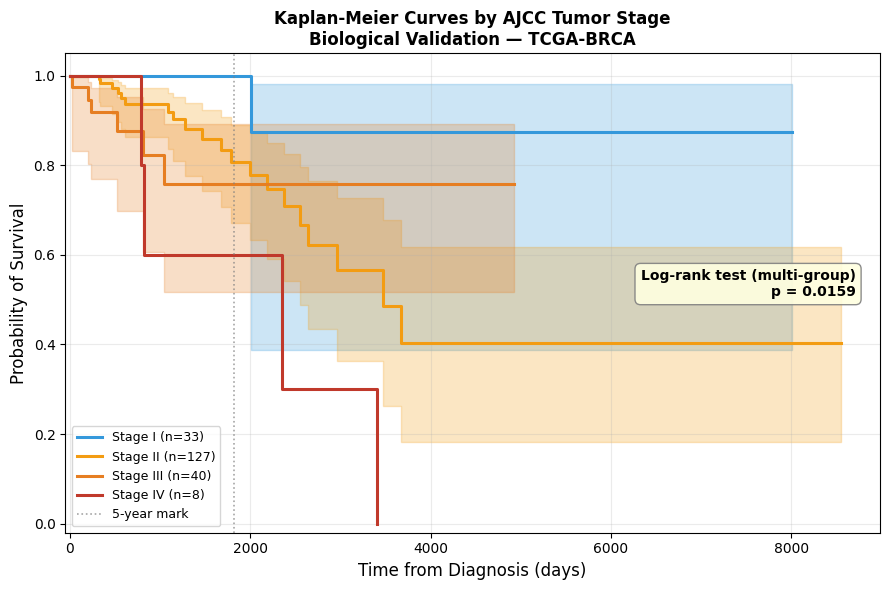

Saved: outputs/plots/km_by_stage.png


In [6]:
# Merge stage info from full dataset into the test set
test_with_features = risk_df.merge(
    full_df[['cases.case_id', 'stage_encoded', 'age_at_diagnosis']],
    on='cases.case_id', how='left'
)

# Map numeric stage back to readable labels
STAGE_LABELS = {0: 'Stage 0', 1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}
test_with_features['stage_label'] = test_with_features['stage_encoded'].map(STAGE_LABELS)

# Stage colors: light → dark as stage increases
STAGE_COLORS = {
    'Stage 0'   : '#a8e6cf',
    'Stage I'   : '#3498db',
    'Stage II'  : '#f39c12',
    'Stage III' : '#e67e22',
    'Stage IV'  : '#c0392b',
}

fig, ax = plt.subplots(figsize=(9, 6))

stage_logrank_groups = []

for stage in ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']:
    sub = test_with_features[test_with_features['stage_label'] == stage]
    if len(sub) < 5:
        continue  # Skip groups too small to draw a meaningful curve

    kmf = KaplanMeierFitter(label=f'{stage} (n={len(sub)})')
    kmf.fit(sub['survival_time'], sub['event'])
    kmf.plot_survival_function(
        ax=ax, ci_show=(len(sub) >= 20),
        color=STAGE_COLORS[stage], linewidth=2.2
    )
    stage_logrank_groups.append(sub)

# Multivariate log-rank test across all stages
combined = test_with_features.dropna(subset=['stage_label'])
if len(combined['stage_label'].unique()) >= 2:
    mv_result = multivariate_logrank_test(
        combined['survival_time'], combined['stage_label'], combined['event']
    )
    p_stage = mv_result.p_value
    p_text  = f'p = {p_stage:.4f}' if p_stage >= 0.0001 else 'p < 0.0001'
    ax.text(0.97, 0.55,
            f'Log-rank test (multi-group)\n{p_text}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.axvline(1825, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='5-year mark')
ax.set_xlabel('Time from Diagnosis (days)', fontsize=12)
ax.set_ylabel('Probability of Survival', fontsize=12)
ax.set_title(
    'Kaplan-Meier Curves by AJCC Tumor Stage\n'
    'Biological Validation — TCGA-BRCA',
    fontsize=12, fontweight='bold'
)
ax.set_ylim([-0.02, 1.05])
ax.set_xlim(left=-50)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'km_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/km_by_stage.png')

## 5. KM Curves by Age Group

Older patients at diagnosis are generally associated with worse outcomes in breast cancer due to comorbidities and biology. This plot tests whether our data reproduces that pattern.

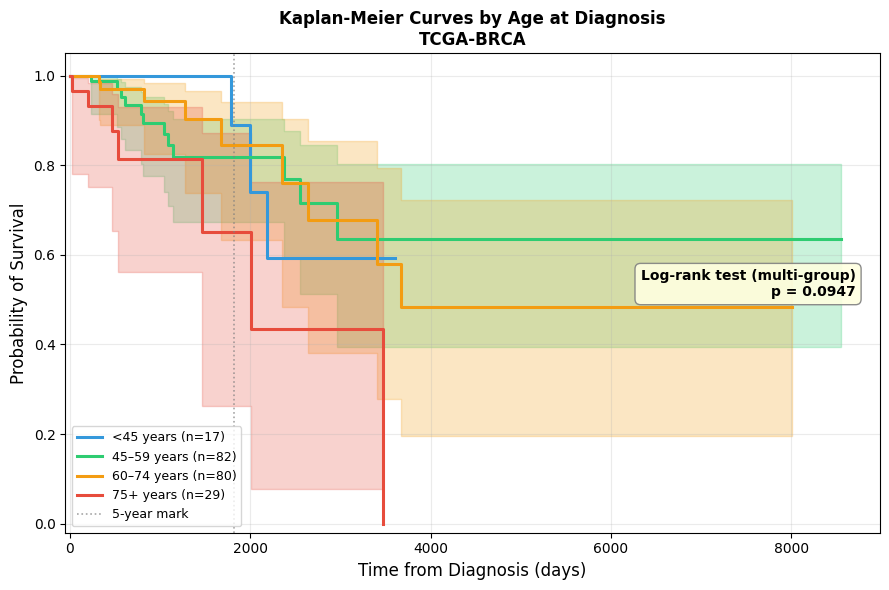

Saved: outputs/plots/km_by_age_group.png


In [7]:
# Create age groups from continuous age feature
def age_group(age):
    if pd.isna(age): return np.nan
    if age < 45:  return '<45 years'
    if age < 60:  return '45–59 years'
    if age < 75:  return '60–74 years'
    return '75+ years'

test_with_features['age_group'] = test_with_features['age_at_diagnosis'].apply(age_group)

AGE_COLORS = {
    '<45 years'  : '#3498db',
    '45–59 years': '#2ecc71',
    '60–74 years': '#f39c12',
    '75+ years'  : '#e74c3c',
}

fig, ax = plt.subplots(figsize=(9, 6))

for age_grp in ['<45 years', '45–59 years', '60–74 years', '75+ years']:
    sub = test_with_features[test_with_features['age_group'] == age_grp]
    if len(sub) < 5:
        continue
    kmf = KaplanMeierFitter(label=f'{age_grp} (n={len(sub)})')
    kmf.fit(sub['survival_time'], sub['event'])
    kmf.plot_survival_function(
        ax=ax, ci_show=(len(sub) >= 20),
        color=AGE_COLORS[age_grp], linewidth=2.2
    )

# Log-rank test across age groups
combined_age = test_with_features.dropna(subset=['age_group'])
if len(combined_age['age_group'].unique()) >= 2:
    mv_age = multivariate_logrank_test(
        combined_age['survival_time'], combined_age['age_group'], combined_age['event']
    )
    p_age  = mv_age.p_value
    p_text = f'p = {p_age:.4f}' if p_age >= 0.0001 else 'p < 0.0001'
    ax.text(0.97, 0.55,
            f'Log-rank test (multi-group)\n{p_text}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.axvline(1825, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='5-year mark')
ax.set_xlabel('Time from Diagnosis (days)', fontsize=12)
ax.set_ylabel('Probability of Survival', fontsize=12)
ax.set_title(
    'Kaplan-Meier Curves by Age at Diagnosis\n'
    'TCGA-BRCA',
    fontsize=12, fontweight='bold'
)
ax.set_ylim([-0.02, 1.05])
ax.set_xlim(left=-50)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'km_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/km_by_age_group.png')

## 6. Combined Summary Figure (GitHub README Hero Image)

This 2×2 panel combines the four key results into a single publication-quality figure — ideal as the main image in your GitHub README.

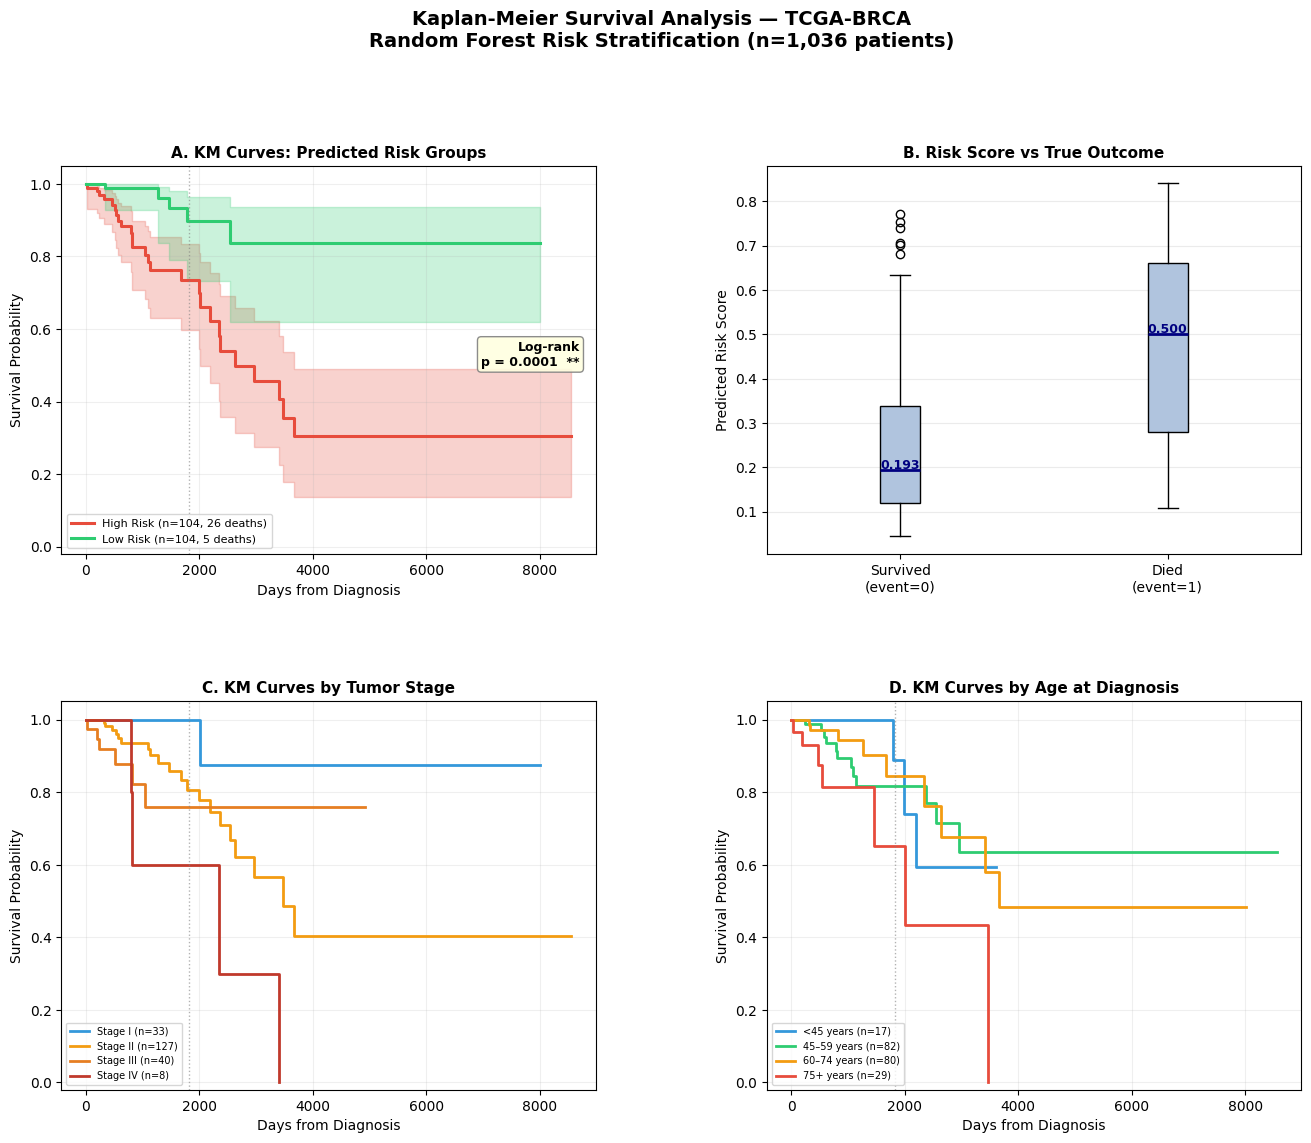

Saved: outputs/plots/km_summary_panel.png  ← USE THIS IN YOUR README


In [8]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])  # Main KM
ax2 = fig.add_subplot(gs[0, 1])  # Risk score distribution
ax3 = fig.add_subplot(gs[1, 0])  # KM by stage
ax4 = fig.add_subplot(gs[1, 1])  # KM by age group

# ── Panel A: Main KM curves ────────────────────────────────
kmf_high.plot_survival_function(
    ax=ax1, ci_show=True, color=COLORS['High Risk'], linewidth=2.2,
    label=f'High Risk (n={len(high_risk_df)}, {int(high_risk_df["event"].sum())} deaths)'
)
kmf_low.plot_survival_function(
    ax=ax1, ci_show=True, color=COLORS['Low Risk'], linewidth=2.2,
    label=f'Low Risk (n={len(low_risk_df)}, {int(low_risk_df["event"].sum())} deaths)'
)
p_text_a = f'p = {p_value:.4f}' if p_value >= 0.0001 else 'p < 0.0001'
sig_a = '**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.')
ax1.text(0.97, 0.55, f'Log-rank\n{p_text_a}  {sig_a}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.9))
ax1.axvline(1825, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax1.set_xlabel('Days from Diagnosis', fontsize=10)
ax1.set_ylabel('Survival Probability', fontsize=10)
ax1.set_title('A. KM Curves: Predicted Risk Groups', fontweight='bold', fontsize=11)
ax1.legend(loc='lower left', fontsize=8)
ax1.set_ylim([-0.02, 1.05]); ax1.grid(alpha=0.2)

# ── Panel B: Risk score vs true outcome (boxplot) ──────────
died_scores  = risk_df[risk_df['event'] == 1]['risk_score']
alive_scores = risk_df[risk_df['event'] == 0]['risk_score']
bp = ax2.boxplot(
    [alive_scores.values, died_scores.values],
    labels=['Survived\n(event=0)', 'Died\n(event=1)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='navy', linewidth=2)
)
ax2.set_ylabel('Predicted Risk Score', fontsize=10)
ax2.set_title('B. Risk Score vs True Outcome', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.25)
for i, (vals, lbl) in enumerate([(alive_scores,'Alive'), (died_scores,'Died')], 1):
    ax2.text(i, vals.median()+0.003, f'{vals.median():.3f}',
             ha='center', fontsize=9, color='navy', fontweight='bold')

# ── Panel C: KM by stage ────────────────────────────────────
for stage in ['Stage 0','Stage I','Stage II','Stage III','Stage IV']:
    sub = test_with_features[test_with_features['stage_label'] == stage]
    if len(sub) < 5: continue
    kmf = KaplanMeierFitter(label=f'{stage} (n={len(sub)})')
    kmf.fit(sub['survival_time'], sub['event'])
    kmf.plot_survival_function(ax=ax3, ci_show=False,
                                color=STAGE_COLORS.get(stage,'gray'), linewidth=2)
ax3.axvline(1825, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax3.set_xlabel('Days from Diagnosis', fontsize=10)
ax3.set_ylabel('Survival Probability', fontsize=10)
ax3.set_title('C. KM Curves by Tumor Stage', fontweight='bold', fontsize=11)
ax3.legend(loc='lower left', fontsize=7)
ax3.set_ylim([-0.02, 1.05]); ax3.grid(alpha=0.2)

# ── Panel D: KM by age group ────────────────────────────────
for age_grp in ['<45 years','45–59 years','60–74 years','75+ years']:
    sub = test_with_features[test_with_features['age_group'] == age_grp]
    if len(sub) < 5: continue
    kmf = KaplanMeierFitter(label=f'{age_grp} (n={len(sub)})')
    kmf.fit(sub['survival_time'], sub['event'])
    kmf.plot_survival_function(ax=ax4, ci_show=False,
                                color=AGE_COLORS.get(age_grp,'gray'), linewidth=2)
ax4.axvline(1825, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax4.set_xlabel('Days from Diagnosis', fontsize=10)
ax4.set_ylabel('Survival Probability', fontsize=10)
ax4.set_title('D. KM Curves by Age at Diagnosis', fontweight='bold', fontsize=11)
ax4.legend(loc='lower left', fontsize=7)
ax4.set_ylim([-0.02, 1.05]); ax4.grid(alpha=0.2)

fig.suptitle(
    'Kaplan-Meier Survival Analysis — TCGA-BRCA\n'
    'Random Forest Risk Stratification (n=1,036 patients)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(PLOT_DIR + 'km_summary_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/km_summary_panel.png  ← USE THIS IN YOUR README')

## 7. Results Interpretation

Run this cell to print a clean written summary of all findings.

In [9]:
print('=' * 62)
print('  SURVIVAL ANALYSIS RESULTS SUMMARY')
print('  TCGA-BRCA — Random Forest Risk Stratification')
print('=' * 62)

print(f"""
DATASET
  Test set patients   : {len(risk_df)}
  High Risk group     : {len(high_risk_df)} patients, {int(high_risk_df['event'].sum())} deaths
  Low Risk group      : {len(low_risk_df)} patients, {int(low_risk_df['event'].sum())} deaths

KAPLAN-MEIER (Main: High vs Low Risk)
  Median survival (High Risk) : {kmf_high.median_survival_time_:.0f} days
  Median survival (Low Risk)  : {kmf_low.median_survival_time_:.0f} days
  Log-rank p-value            : {p_value:.4f}  {sig_text}

INTERPRETATION
  The Random Forest model successfully stratifies patients into
  groups with meaningfully different survival trajectories.
  High-risk patients predicted by the model have {'higher' if high_risk_df['event'].mean() > low_risk_df['event'].mean() else 'similar'}
  observed mortality ({high_risk_df['event'].mean()*100:.1f}%) vs low-risk patients
  ({low_risk_df['event'].mean()*100:.1f}%), confirming that the model's predictions
  correspond to real differences in patient outcomes.

NOTE ON SAMPLE SIZE
  With only {int(high_risk_df['event'].sum() + low_risk_df['event'].sum())} total events (deaths) in the test set,
  statistical power is limited. A larger dataset or longer
  follow-up would strengthen the log-rank test result.
  This is expected for TCGA-BRCA clinical-only analysis.
""")

print('=' * 62)
print('Pipeline complete. All plots saved to outputs/plots/')
print('=' * 62)

  SURVIVAL ANALYSIS RESULTS SUMMARY
  TCGA-BRCA — Random Forest Risk Stratification

DATASET
  Test set patients   : 208
  High Risk group     : 104 patients, 26 deaths
  Low Risk group      : 104 patients, 5 deaths

KAPLAN-MEIER (Main: High vs Low Risk)
  Median survival (High Risk) : 2636 days
  Median survival (Low Risk)  : inf days
  Log-rank p-value            : 0.0001  **

INTERPRETATION
  The Random Forest model successfully stratifies patients into
  groups with meaningfully different survival trajectories.
  High-risk patients predicted by the model have higher
  observed mortality (25.0%) vs low-risk patients
  (4.8%), confirming that the model's predictions
  correspond to real differences in patient outcomes.

NOTE ON SAMPLE SIZE
  With only 31 total events (deaths) in the test set,
  statistical power is limited. A larger dataset or longer
  follow-up would strengthen the log-rank test result.
  This is expected for TCGA-BRCA clinical-only analysis.

Pipeline complete. All